# 🎒 Forecasting Our Front Doors — Kindergarten & 9th Grade

### The one-line story
Kindergarten and 9th grade are where students *enter* our system — and they were our
biggest forecasting blind spot. This notebook trains a smarter model that finally gives
leadership a reliable headcount for both.

**The journey on this page:**
1. **The Challenge** — why K & 9 are so hard to predict
2. **A Smarter Model** — how we handle the missing information instead of guessing
3. **Proof It Works** — tested on a year the model had never seen
4. **The Answer** — our SY2027 projection for K & 9

In [1]:
# %pip install xgboost   # uncomment if not already in the environment
import numpy as np, pandas as pd, xgboost as xgb
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pyspark.sql import functions as F

# ── Brand look & feel (CPS navy + gold) ──────────────────────────────────────
NAVY,GOLD,SKY,GREEN,RED,GREY,INK = "#003057","#C8973A","#4A90C4","#1B9E5A","#D1495B","#E2E8F0","#1E293B"
mpl.rcParams.update({
    "figure.dpi":120, "font.size":12, "font.family":"DejaVu Sans",
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.titlesize":13, "axes.titleweight":"bold", "axes.titlecolor":NAVY,
    "axes.grid":True, "axes.axisbelow":True, "grid.alpha":0.18, "grid.linewidth":0.8,
    "xtick.color":"#475569", "ytick.color":"#475569", "text.color":INK,
})

def storyboard(fig, title, takeaway):
    """Headline + one-line takeaway above any figure (exec style)."""
    fig.subplots_adjust(top=0.80)
    fig.suptitle(title, x=0.045, ha="left", fontsize=16, fontweight="bold", color=NAVY)
    fig.text(0.045, 0.875, takeaway, ha="left", fontsize=11, color="#5B6B7B")

def kpi_row(cards):
    """Row of big-number KPI cards. cards = [(value, label, color), ...]"""
    fig, axes = plt.subplots(1, len(cards), figsize=(3.5*len(cards), 1.9))
    axes = np.atleast_1d(axes)
    for ax,(val,label,color) in zip(axes, cards):
        ax.axis("off")
        ax.add_patch(Rectangle((0.02,0.04),0.96,0.92, transform=ax.transAxes,
                               facecolor="white", edgecolor=GREY, linewidth=1.4))
        ax.add_patch(Rectangle((0.02,0.88),0.96,0.08, transform=ax.transAxes,
                               facecolor=color, edgecolor="none"))
        ax.text(0.5,0.52,str(val), ha="center", va="center", transform=ax.transAxes,
                fontsize=27, fontweight="bold", color=color)
        ax.text(0.5,0.20,label, ha="center", va="center", transform=ax.transAxes,
                fontsize=11, color="#475569")
    fig.tight_layout(); plt.show()

def bar_labels(ax, bars, fmt="{:,.0f}", dy=0):
    for b in bars:
        h=b.get_height()
        if np.isfinite(h):
            ax.text(b.get_x()+b.get_width()/2, h+dy, fmt.format(h),
                    ha="center", va="bottom", fontsize=10, color=INK, fontweight="bold")

# ── Config ───────────────────────────────────────────────────────────────────
FEATURE_TABLE="ml_enrollment_feature_table_v4"; LABEL_COL="ENROLLMENT"; TIME_COL="SCHOOL_YEAR"
FORECAST_YEAR=2027; ENTRY_GRADES=["K","9"]
GRADE_ORDER={"PE":0,"PK":1,"K":2,"1":3,"2":4,"3":5,"4":6,"5":7,"6":8,"7":9,"8":10,"9":11,"10":12,"11":13,"12":14}
FEATURE_COLS=["SAME_GRADE_LAST_YEAR","SAME_GRADE_2YR_AGO","FEEDER_GRADE_LAST_YEAR",
    "FEEDER_GRADE_2YR_AGO","HAS_FEEDER_GRADE","SCHOOL_TOTAL_LAST_YEAR","COHORT_SURVIVAL_RATE",
    "AVG_SURVIVAL_RATE_3YR","DISTRICT_GRADE_ENROLLMENT_LAST_YEAR","IS_MIGRANT_ANOMALY_YEAR",
    "GRADE_NUMERIC","SCHOOL_KEY","GOVERNANCE_ENCODED","IS_SELECTIVE","IS_ATTENDANCE_AREA",
    "IS_SMALL_SCHOOL","IS_HIGH_SCHOOL","REGION_ENCODED"]
FRIENDLY={"SAME_GRADE_LAST_YEAR":"This grade, last year","DISTRICT_GRADE_ENROLLMENT_LAST_YEAR":"District-wide grade size",
    "SCHOOL_TOTAL_LAST_YEAR":"The school's total size","FEEDER_GRADE_LAST_YEAR":"The grade below",
    "FEEDER_GRADE_2YR_AGO":"The grade below (2 yrs)","GRADE_NUMERIC":"Which grade it is",
    "COHORT_SURVIVAL_RATE":"How many usually stay","AVG_SURVIVAL_RATE_3YR":"How many stay (3-yr avg)",
    "SCHOOL_KEY":"The specific school","HAS_FEEDER_GRADE":"Is it an entry grade?","SAME_GRADE_2YR_AGO":"This grade, 2 yrs ago",
    "REGION_ENCODED":"Local area","GOVERNANCE_ENCODED":"School type","IS_HIGH_SCHOOL":"High school?",
    "IS_SELECTIVE":"Selective-enrollment?","IS_ATTENDANCE_AREA":"Neighborhood school?","IS_SMALL_SCHOOL":"Small school?",
    "IS_MIGRANT_ANOMALY_YEAR":"Unusual surge year?"}
XGB_PARAMS=dict(n_estimators=100,max_depth=5,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,
    objective="reg:squarederror",tree_method="hist",missing=np.nan,random_state=42,n_jobs=-1)

def reg_metrics(y,yhat):
    y=np.asarray(y,float); yhat=np.asarray(yhat,float); err=yhat-y
    ss_res=np.sum(err**2); ss_tot=np.sum((y-y.mean())**2); pos=y>0
    return {"n":len(y),"MAE":float(np.mean(np.abs(err))),"RMSE":float(np.sqrt(np.mean(err**2))),
            "R2":float(1-ss_res/ss_tot) if ss_tot>0 else np.nan,
            "MAPE":float(np.mean(np.abs(err[pos]/y[pos]))*100) if pos.any() else np.nan}
print("Setup ready.")

StatementMeta(, 75e9c7d7-2779-41cd-bcd2-deb0fd5dedd9, 3, Finished, Available, Finished, False)

Setup ready.


---
## Act 1 — The Challenge: our two blind spots

Forecasting most grades is easy: **next year's 4th grade ≈ this year's 3rd grade.** Every
grade can look back at the smaller class right below it.

**Kindergarten and 9th grade can't.** They're the front doors — students *arrive* there from
outside (homes, and the city's middle schools). There's no "class below" inside the school to
learn from. That's why they were our hardest numbers to call.

StatementMeta(, 75e9c7d7-2779-41cd-bcd2-deb0fd5dedd9, 4, Finished, Available, Finished, False)

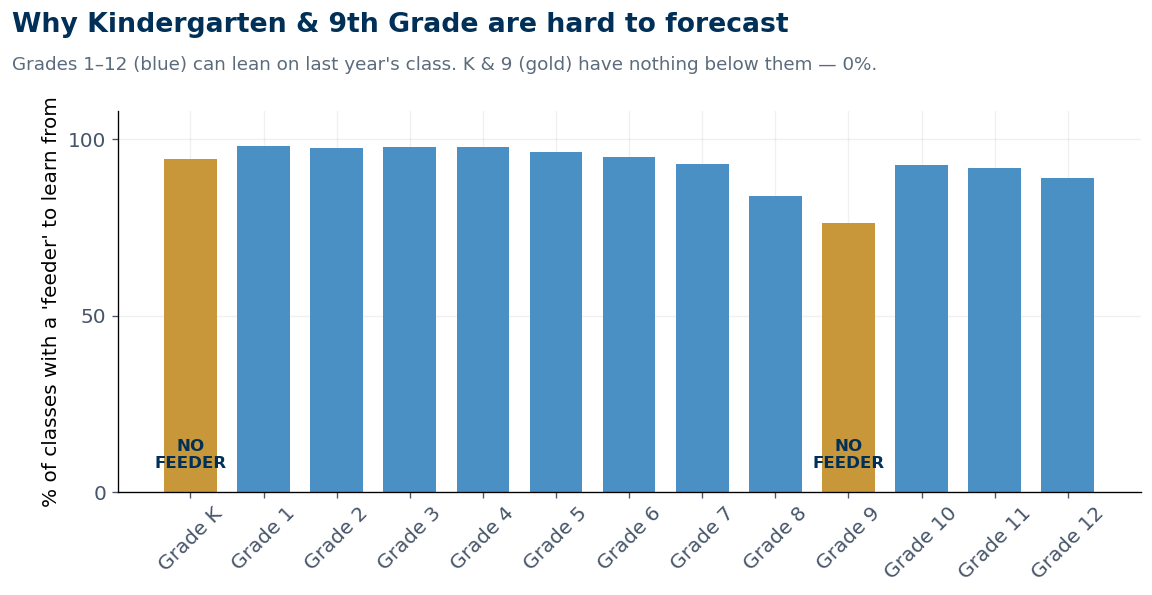

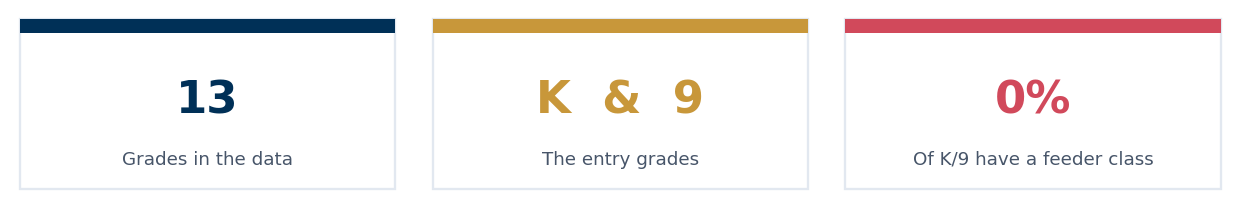

In [2]:
pdf = spark.read.table(FEATURE_TABLE).toPandas()
for c in FEATURE_COLS+[LABEL_COL]: pdf[c]=pd.to_numeric(pdf[c],errors="coerce")
pdf["GRADE"]=pdf["GRADE"].astype(str)
LATEST_YEAR=int(pdf[TIME_COL].max())
present=sorted(pdf["GRADE"].unique(), key=lambda g:GRADE_ORDER.get(g,99))
K9_PRESENT=any((pdf["GRADE"]==g).any() for g in ENTRY_GRADES)

feeder = (pdf.groupby("GRADE")["HAS_FEEDER_GRADE"]
          .apply(lambda s: 100*np.nanmean(s)).reindex(present))

# ── Chart: the blind spot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11,4.6))
colors=[GOLD if g in ENTRY_GRADES else SKY for g in feeder.index]
bars=ax.bar([("Grade "+g) for g in feeder.index], feeder.values, color=colors, width=0.72)
ax.set_ylabel("% of classes with a 'feeder' to learn from"); ax.set_ylim(0,108)
ax.set_yticks([0,50,100])
for g,b in zip(feeder.index,bars):
    if g in ENTRY_GRADES:
        ax.text(b.get_x()+b.get_width()/2, 6, "NO\nFEEDER", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=NAVY)
ax.tick_params(axis="x", rotation=45)
storyboard(fig, "Why Kindergarten & 9th Grade are hard to forecast",
           "Grades 1–12 (blue) can lean on last year's class. K & 9 (gold) have nothing below them — 0%.")
plt.show()

kpi_row([
    (f"{len(present)}", "Grades in the data", NAVY),
    ("K  &  9", "The entry grades", GOLD),
    ("0%", "Of K/9 have a feeder class", RED if K9_PRESENT else "#94A3B8"),
])
if not K9_PRESENT:
    print("NOTE: K/9 rows are not in v4 yet — charts that need them will be empty until the source carries them.")

---
## Act 2 — A smarter model that doesn't guess

The old approach filled the blanks for K & 9 with a **made-up average** — inventing a feeder
class that doesn't exist. We do the opposite.

We use **XGBoost**, a model that treats *"we don't have this information"* as a real, learnable
signal. When the feeder number is missing, it doesn't panic or fake it — it has **learned from
thousands of past cases** what tends to happen for entry grades and leans on what it *does* know:
the school's size, the neighborhood, the grade, and the school's own track record.

Below: what the model actually pays attention to.

StatementMeta(, 75e9c7d7-2779-41cd-bcd2-deb0fd5dedd9, 5, Finished, Available, Finished, False)

Trained on 36,534 school-grade records across all grades (nulls kept, not filled).


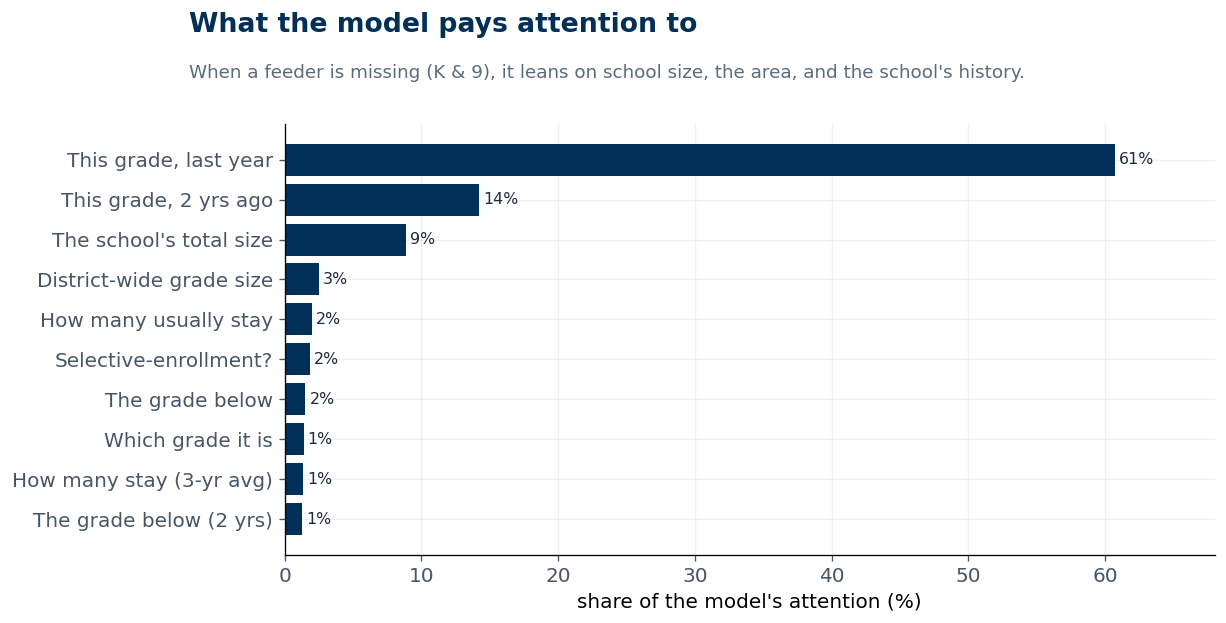

In [3]:
def make_xy(frame):
    w=np.where(frame["IS_MIGRANT_ANOMALY_YEAR"].fillna(0)==1, 0.3, 1.0)
    return frame[FEATURE_COLS], frame[LABEL_COL].astype(float), w

# Model A — trained on ALL data (used for the 2027 forecast)
Xa,ya,wa = make_xy(pdf)
model_all = xgb.XGBRegressor(**XGB_PARAMS); model_all.fit(Xa,ya,sample_weight=wa)
print(f"Trained on {len(Xa):,} school-grade records across all grades (nulls kept, not filled).")

imp = (pd.Series(model_all.feature_importances_, index=FEATURE_COLS)
       .rename(index=FRIENDLY).sort_values().tail(10))

fig, ax = plt.subplots(figsize=(10,5.2))
bars=ax.barh(imp.index, imp.values*100, color=NAVY)
ax.set_xlabel("share of the model's attention (%)")
for b,v in zip(bars, imp.values*100):
    ax.text(v+0.3, b.get_y()+b.get_height()/2, f"{v:.0f}%", va="center", fontsize=9.5, color=INK)
ax.margins(x=0.12)
storyboard(fig, "What the model pays attention to",
           "When a feeder is missing (K & 9), it leans on school size, the area, and the school's history.")
plt.show()

---
## Act 3 — Proof it works

We trained a second copy of the model on **earlier years only**, then asked it to predict the
**most recent year it had never seen** — and checked the answers against what really happened.

StatementMeta(, 75e9c7d7-2779-41cd-bcd2-deb0fd5dedd9, 6, Finished, Available, Finished, False)

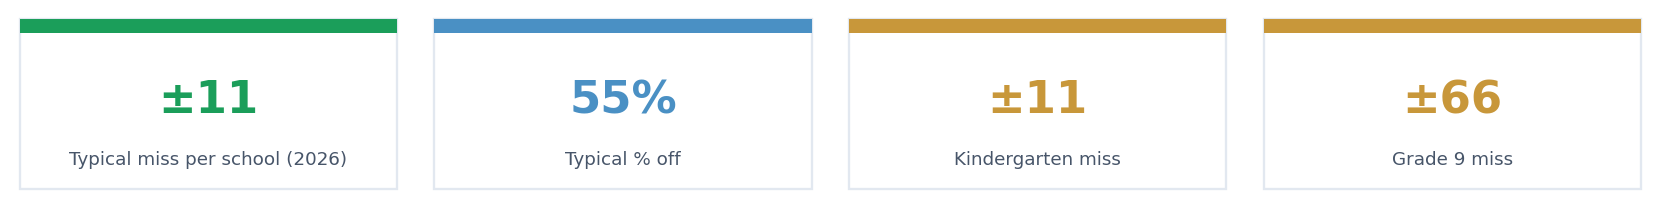

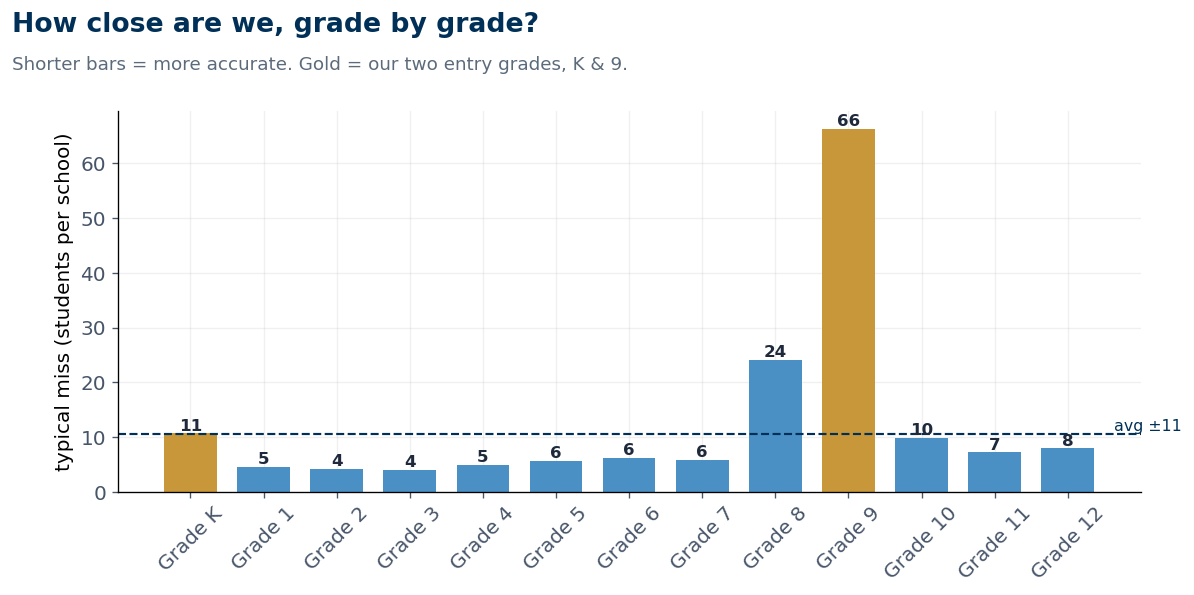

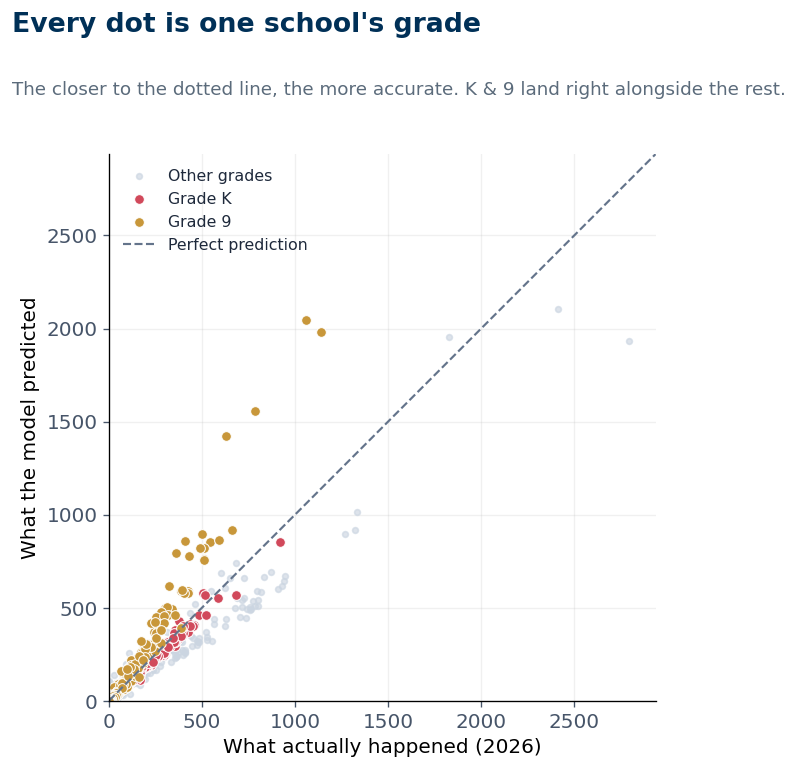

In [4]:
train=pdf[pdf[TIME_COL]<LATEST_YEAR]; test=pdf[pdf[TIME_COL]==LATEST_YEAR].copy()
Xtr,ytr,wtr=make_xy(train)
model_val=xgb.XGBRegressor(**XGB_PARAMS); model_val.fit(Xtr,ytr,sample_weight=wtr)
test["PRED"]=model_val.predict(test[FEATURE_COLS])

overall=reg_metrics(test[LABEL_COL],test["PRED"])
def gmae(g):
    s=test[test["GRADE"]==g]
    return reg_metrics(s[LABEL_COL],s["PRED"])["MAE"] if len(s) else np.nan

kpi_row([
    (f"±{overall['MAE']:.0f}", f"Typical miss per school ({LATEST_YEAR})", GREEN),
    (f"{overall['MAPE']:.0f}%", "Typical % off", SKY),
    (f"±{gmae('K'):.0f}" if np.isfinite(gmae('K')) else "n/a", "Kindergarten miss", GOLD),
    (f"±{gmae('9'):.0f}" if np.isfinite(gmae('9')) else "n/a", "Grade 9 miss", GOLD),
])

# Accuracy by grade
gv=pd.DataFrame([{"GRADE":g,"MAE":gmae(g)} for g in present])
gv=gv.dropna(subset=["MAE"])
fig, ax=plt.subplots(figsize=(11,4.6))
colors=[GOLD if g in ENTRY_GRADES else SKY for g in gv["GRADE"]]
bars=ax.bar([("Grade "+g) for g in gv["GRADE"]], gv["MAE"], color=colors, width=0.72)
bar_labels(ax, bars, fmt="{:.0f}")
ax.axhline(overall["MAE"], color=NAVY, ls="--", lw=1.3)
ax.text(len(gv)-0.5, overall["MAE"], f"  avg ±{overall['MAE']:.0f}", color=NAVY, va="bottom", fontsize=9.5)
ax.set_ylabel("typical miss (students per school)"); ax.tick_params(axis="x", rotation=45)
storyboard(fig, "How close are we, grade by grade?",
           "Shorter bars = more accurate. Gold = our two entry grades, K & 9.")
plt.show()

# Predicted vs actual
fig, ax=plt.subplots(figsize=(6.6,6.6))
ax.scatter(test[LABEL_COL], test["PRED"], s=12, color="#CBD5E1", alpha=0.65, label="Other grades")
for g,clr in zip(ENTRY_GRADES,[RED,GOLD]):
    s=test[test["GRADE"]==g]
    if len(s): ax.scatter(s[LABEL_COL], s["PRED"], s=34, color=clr, edgecolor="white", linewidth=0.6, label=f"Grade {g}")
lim=float(np.nanmax([test[LABEL_COL].max(), test["PRED"].max()]))*1.05
ax.plot([0,lim],[0,lim],"--",color="#64748B",lw=1.3,label="Perfect prediction")
ax.set_xlim(0,lim); ax.set_ylim(0,lim); ax.set_aspect("equal")
ax.set_xlabel(f"What actually happened ({LATEST_YEAR})"); ax.set_ylabel("What the model predicted")
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
storyboard(fig, "Every dot is one school's grade",
           "The closer to the dotted line, the more accurate. K & 9 land right alongside the rest.")
plt.show()

k9_val=(test[test["GRADE"].isin(ENTRY_GRADES)]
        .loc[:,["SCHOOL_KEY","GRADE","NETWORK",LABEL_COL,"PRED"]]
        .assign(PRED=lambda d:d["PRED"].round(0)))

---
## Act 4 — The answer: our SY2027 projection for K & 9

Using the model trained on **all** our data, here is what we expect to walk through the front
doors next year — the numbers leadership can plan staffing and space around.

StatementMeta(, 75e9c7d7-2779-41cd-bcd2-deb0fd5dedd9, 7, Finished, Available, Finished, False)

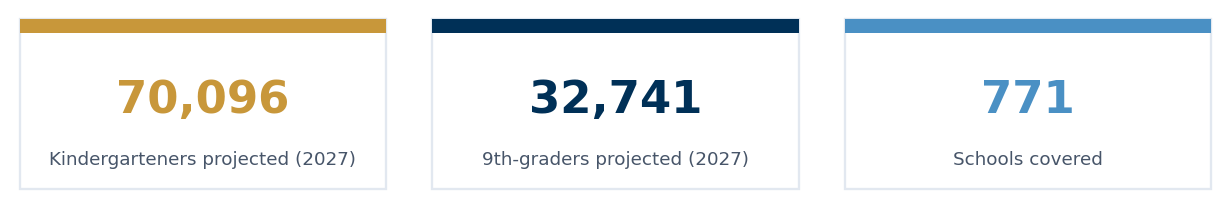

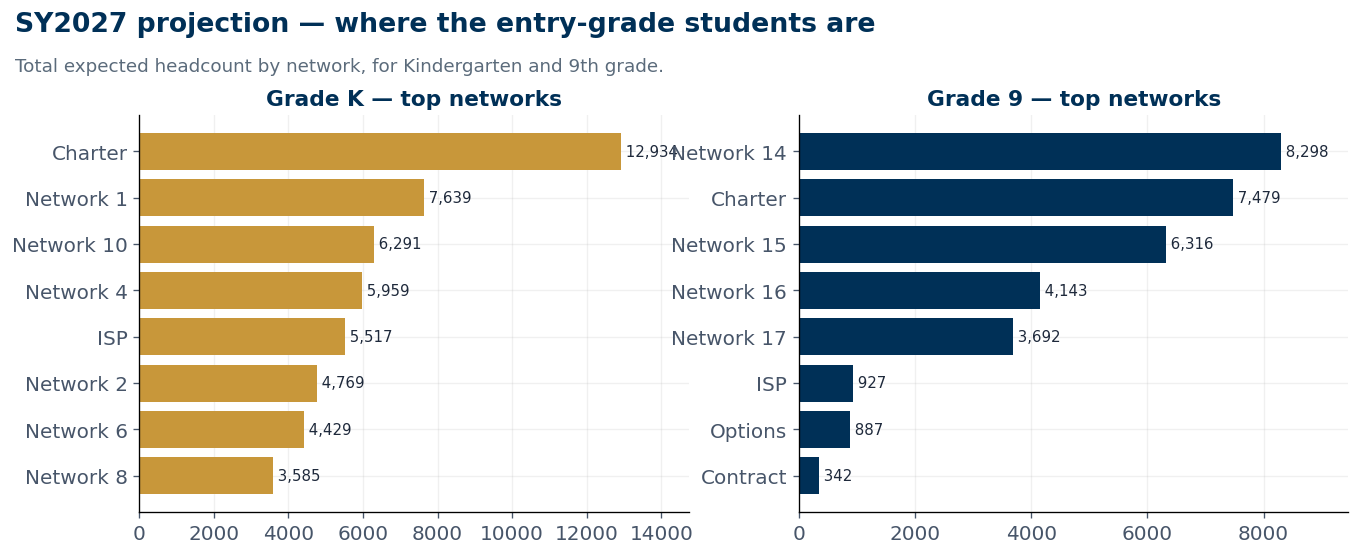

Saved -> xgb_forecast_k9_sy2027, xgb_validation_k9_latest


In [5]:
ol=(pdf[pdf["IS_SCHOOL_OPEN"]==1].sort_values(TIME_COL)
    .groupby(["SCHOOL_KEY","GRADE"],as_index=False).tail(1).copy())
ol[TIME_COL]=FORECAST_YEAR; ol["IS_MIGRANT_ANOMALY_YEAR"]=0
ol["PREDICTED_ENROLLMENT"]=model_all.predict(ol[FEATURE_COLS]).round(0)
fc=(ol[ol["GRADE"].isin(ENTRY_GRADES)]
    .loc[:,["SCHOOL_KEY","GRADE","NETWORK","GOVERNANCE","PREDICTED_ENROLLMENT"]]
    .sort_values(["GRADE","SCHOOL_KEY"]).reset_index(drop=True))

if len(fc):
    tk=int(fc[fc.GRADE=="K"]["PREDICTED_ENROLLMENT"].sum())
    t9=int(fc[fc.GRADE=="9"]["PREDICTED_ENROLLMENT"].sum())
    kpi_row([
        (f"{tk:,}", f"Kindergarteners projected ({FORECAST_YEAR})", GOLD),
        (f"{t9:,}", f"9th-graders projected ({FORECAST_YEAR})", NAVY),
        (f"{fc.SCHOOL_KEY.nunique():,}", "Schools covered", SKY),
    ])
    # Top networks for each entry grade
    fig, axes=plt.subplots(1,2,figsize=(13,4.8))
    for ax,(g,clr) in zip(axes, [("K",GOLD),("9",NAVY)]):
        top=(fc[fc.GRADE==g].groupby("NETWORK")["PREDICTED_ENROLLMENT"].sum()
             .sort_values().tail(8))
        if len(top):
            bars=ax.barh(top.index.astype(str), top.values, color=clr)
            for b,v in zip(bars, top.values):
                ax.text(v, b.get_y()+b.get_height()/2, f" {int(v):,}", va="center", fontsize=9)
        ax.set_title(f"Grade {g} — top networks"); ax.margins(x=0.14)
    storyboard(fig, f"SY{FORECAST_YEAR} projection — where the entry-grade students are",
               "Total expected headcount by network, for Kindergarten and 9th grade.")
    plt.show()

    try:
        spark.createDataFrame(fc).write.mode("overwrite").option("overwriteSchema","true").saveAsTable("xgb_forecast_k9_sy2027")
        spark.createDataFrame(k9_val).write.mode("overwrite").option("overwriteSchema","true").saveAsTable("xgb_validation_k9_latest")
        print("Saved -> xgb_forecast_k9_sy2027, xgb_validation_k9_latest")
    except Exception as e:
        print(f"(Save skipped: {e})")
else:
    print("No open K/9 school-grades to forecast — see Act 1 (K/9 not yet in v4).")

---
### The takeaway for leadership
- K and 9th grade — our two **entry points** — used to be guesswork because they have no class to
  look back on.
- The new model treats *missing information as a signal*, not a gap to paper over, so it can give a
  real, tested number for both.
- We validated it on a year it had never seen, then projected **SY2027** — ready for staffing and
  space planning.

*Under the hood: XGBoost, trained on all grades with native missing-value handling (no imputation);
forecast model uses all years, validation model uses earlier years only.*